In [7]:
# 01_eda.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


✅ Loaded 1555 utterances from 294 meetings

📝 Avg words per utterance: 18.25

📊 Utterance-Level Role Distribution:
role
other     545
leader    363
junior    362
hr        285
Name: count, dtype: int64

🧠 Speaker-level samples: 1133

🎯 Speaker-Level Role Distribution:
role
other     475
leader    275
junior    268
hr        115
Name: count, dtype: int64

👥 Speakers per meeting → min=2, max=5, mean=3.84

🧪 Role Purity Checks:
num_roles  multiple_leaders  no_leader
4          False             False        110
3          False             False         99
2          False             True          29
3          True              False         27
1          False             True          18
2          False             False         10
4          True              False          1
Name: count, dtype: int64

📄 Report written to reports/eda_report.md


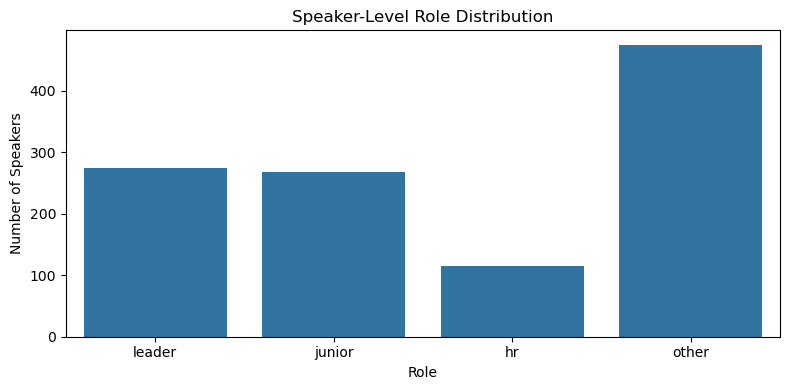

🖼️ Plot saved → reports/role_distribution_speaker_level.png


In [8]:
# ============================================================
# 01_eda_speaker_level.py
# EDA for Speaker-Level Role Detection
# Supports: leader | junior | hr | other
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -------------------- Config --------------------
INPUT_PATH = "data/labeled_roles.csv"

REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_REPORT = REPORT_DIR / "eda_report.md"
ROLE_COUNT_CSV = REPORT_DIR / "utterance_label_counts.csv"
SPEAKER_ROLE_COUNT_CSV = REPORT_DIR / "speaker_label_counts.csv"
SPEAKERS_PER_MEETING_CSV = REPORT_DIR / "speakers_per_meeting.csv"
ROLE_PURITY_CSV = REPORT_DIR / "role_purity.csv"
PLOT_PATH = REPORT_DIR / "role_distribution_speaker_level.png"

# -------------------- Load & Validate --------------------
if not Path(INPUT_PATH).exists():
    raise FileNotFoundError(f"❌ Input file not found: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)

required_cols = {"meeting_id", "speaker_id", "full_text", "role"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"❌ Missing required columns: {sorted(missing)}")

print(f"✅ Loaded {len(df)} utterances from {df.meeting_id.nunique()} meetings")

# ============================================================
# Normalize Roles
# ============================================================

df["role_raw"] = df["role"]

df["role"] = (
    df["role"]
    .astype(str)
    .str.strip()
    .str.lower()
)

ROLE_CANONICAL_MAP = {
    "leader": "leader",
    "lead": "leader",
    "manager": "leader",

    "junior": "junior",
    "developer": "junior",
    "employee": "junior",

    "hr": "hr",
    "human resources": "hr",
    "moderator": "hr",

    "other": "other",
    "observer": "other",
    "unknown": "other",
}

df["role"] = df["role"].map(lambda r: ROLE_CANONICAL_MAP.get(r, "other"))

# ============================================================
# Utterance-Level Statistics
# ============================================================

df["word_count"] = df["full_text"].astype(str).str.split().str.len()
df["char_len"] = df["full_text"].astype(str).str.len()

print(f"\n📝 Avg words per utterance: {df['word_count'].mean():.2f}")

# Short utterance flag
df["is_short_utterance"] = df["word_count"] < 5
short_rate = df["is_short_utterance"].mean() * 100

# Utterance-level role distribution
utterance_role_counts = df["role"].value_counts()
utterance_role_counts.to_frame("count").to_csv(ROLE_COUNT_CSV)

print("\n📊 Utterance-Level Role Distribution:")
print(utterance_role_counts)

# ============================================================
# 🔥 Speaker-Level Aggregation (Aligned With Model)
# ============================================================

speaker_df = (
    df.groupby(["meeting_id", "speaker_id", "role"])
    .agg({
        "full_text": "count"
    })
    .reset_index()
    .rename(columns={"full_text": "num_utterances"})
)

print(f"\n🧠 Speaker-level samples: {len(speaker_df)}")

speaker_role_counts = speaker_df["role"].value_counts()
speaker_role_counts.to_frame("count").to_csv(SPEAKER_ROLE_COUNT_CSV)

print("\n🎯 Speaker-Level Role Distribution:")
print(speaker_role_counts)

# ============================================================
# Speakers Per Meeting
# ============================================================

speakers_per_meeting = speaker_df.groupby("meeting_id")["speaker_id"].nunique()
speakers_per_meeting.to_csv(SPEAKERS_PER_MEETING_CSV, header=["num_speakers"])

print(
    f"\n👥 Speakers per meeting → "
    f"min={speakers_per_meeting.min()}, "
    f"max={speakers_per_meeting.max()}, "
    f"mean={speakers_per_meeting.mean():.2f}"
)

# ============================================================
# Role Purity (Speaker-Level)
# ============================================================

role_purity = (
    speaker_df.groupby("meeting_id")["role"]
    .value_counts()
    .unstack(fill_value=0)
)

role_purity["num_roles"] = (role_purity > 0).sum(axis=1)
role_purity["multiple_leaders"] = role_purity.get("leader", 0) > 1
role_purity["no_leader"] = role_purity.get("leader", 0) == 0

role_purity.to_csv(ROLE_PURITY_CSV)

print("\n🧪 Role Purity Checks:")
print(role_purity[["num_roles", "multiple_leaders", "no_leader"]].value_counts())

# ============================================================
# Markdown Report
# ============================================================

try:
    utterance_md = utterance_role_counts.to_markdown()
except:
    utterance_md = utterance_role_counts.to_string()

try:
    speaker_md = speaker_role_counts.to_markdown()
except:
    speaker_md = speaker_role_counts.to_string()

report = f"""
# EDA Report – Speaker-Level Role Detection

## Dataset Overview
- Total utterances: {len(df)}
- Total speakers: {len(speaker_df)}
- Meetings: {df.meeting_id.nunique()}
- Avg words per utterance: {df['word_count'].mean():.2f}
- Short utterances (<5 words): {short_rate:.1f}%

## Utterance-Level Role Distribution
{utterance_md}

## Speaker-Level Role Distribution
{speaker_md}

## Speakers per Meeting
- Min: {speakers_per_meeting.min()}
- Max: {speakers_per_meeting.max()}
- Mean: {speakers_per_meeting.mean():.2f}

## Role Consistency Checks
- Meetings with multiple leaders
- Meetings with no leader
- Meetings with multiple active roles

(See role_purity.csv for details)
"""

OUTPUT_REPORT.write_text(report, encoding="utf-8")
print(f"\n📄 Report written to {OUTPUT_REPORT}")

# ============================================================
# Visualization (Speaker-Level)
# ============================================================

plt.figure(figsize=(8, 4))

ROLE_ORDER = ["leader", "junior", "hr", "other"]
ROLE_ORDER = [r for r in ROLE_ORDER if r in speaker_role_counts.index]

sns.countplot(data=speaker_df, x="role", order=ROLE_ORDER)

plt.title("Speaker-Level Role Distribution")
plt.xlabel("Role")
plt.ylabel("Number of Speakers")
plt.tight_layout()
plt.savefig(PLOT_PATH, bbox_inches="tight")
plt.show()

print(f"🖼️ Plot saved → {PLOT_PATH}")
